# 03. Data Mining: Association Rules & Clustering

## Superstore Sales Data Mining Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data.loader import DataLoader
from src.data.cleaner import DataCleaner
from src.features.builder import FeatureBuilder
from src.mining.association import AssociationMiner
from src.mining.clustering import ClusterMiner
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load & Prepare Data

In [2]:
# Load data
loader = DataLoader()
df = loader.generate_sample_data(n_orders=2000)

# Clean data
cleaner = DataCleaner(df)
df = cleaner.handle_missing_values()
df, _ = cleaner.handle_duplicates()

# Create features
builder = FeatureBuilder(df)
rfm = builder.create_rfm_features()
basket = builder.create_basket_data(min_items=2)

print(f"RFM shape: {rfm.shape}")
print(f"Basket transactions: {len(basket)}")

INFO:src.data.loader:Generated 6986 sample records
INFO:src.data.cleaner:Handling missing values...
INFO:src.data.cleaner:Handling duplicates...
INFO:src.data.cleaner:Removed 0 duplicate rows
INFO:src.features.builder:Creating RFM features...
INFO:src.features.builder:Created RFM features for 849 customers
INFO:src.features.builder:Segment distribution:
Segment
Loyal Customers        283
New Customers          200
Potential Loyalists    110
Lost                    84
At Risk                 59
Champions               57
Promising               56
Name: count, dtype: int64
INFO:src.features.builder:Creating basket data...
INFO:src.features.builder:Created 1953 baskets with min 2 items


RFM shape: (849, 11)
Basket transactions: 1953


## 2. Association Rule Mining

In [3]:
# Prepare transactions
transactions = basket['Items'].tolist()

# Run Apriori
miner = AssociationMiner(min_support=0.02, min_confidence=0.3, min_lift=1.0)
result = miner.fit(transactions)

# Top rules
print("Top 10 Association Rules:")
top_rules = miner.get_top_rules(n=10, sort_by='lift')
print(top_rules)

INFO:src.mining.association:Fitting Apriori with min_support=0.02, min_confidence=0.3
INFO:src.mining.association:Found 91 frequent itemsets and 0 rules


Top 10 Association Rules:
Empty DataFrame
Columns: []
Index: []


In [4]:
# Metrics
metrics = miner.get_rule_metrics()
print("\nRule Metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value}")


Rule Metrics:


In [5]:
# Insights
print("\nBusiness Insights from Association Rules:")
for insight in miner.generate_insights():
    print(f"  - {insight}")


Business Insights from Association Rules:
  - No significant association rules found.


## 3. Clustering Analysis

INFO:src.mining.clustering:Finding optimal K in range [2, 3, 4, 5, 6, 7]...
INFO:src.mining.clustering:K=2: Silhouette=0.4255, DBI=0.9087, CH=808.8695
INFO:src.mining.clustering:K=3: Silhouette=0.3890, DBI=0.8624, CH=845.9223
INFO:src.mining.clustering:K=4: Silhouette=0.3837, DBI=0.8975, CH=854.7813
INFO:src.mining.clustering:K=5: Silhouette=0.3874, DBI=0.8854, CH=819.1115
INFO:src.mining.clustering:K=6: Silhouette=0.3532, DBI=0.9005, CH=782.0641
INFO:src.mining.clustering:K=7: Silhouette=0.3385, DBI=0.9490, CH=771.5273
INFO:src.mining.clustering:Best K by silhouette: 2


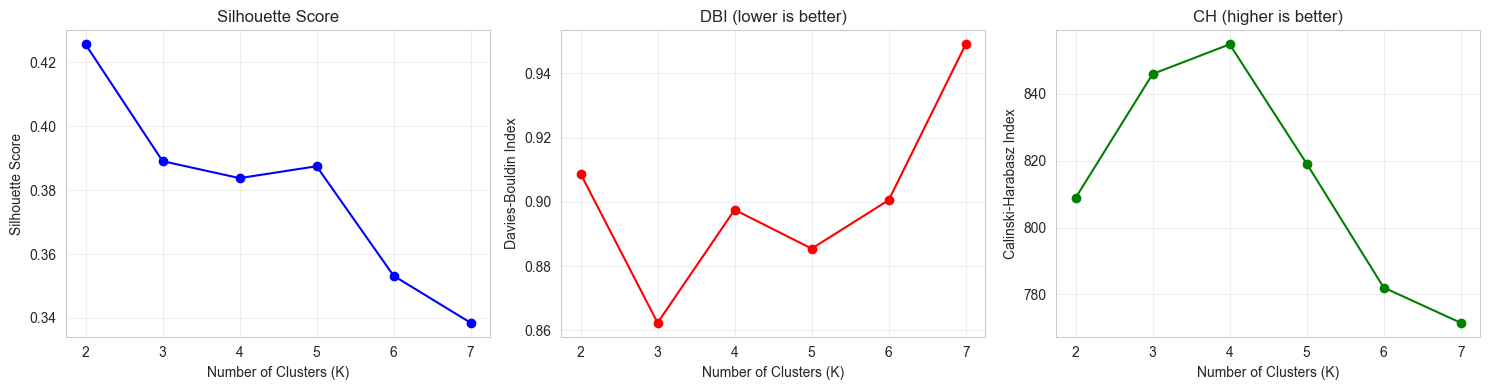

Saved: outputs/figures/07_optimal_k.png


In [6]:
# Prepare RFM for clustering
feature_cols = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
features = scaler.fit_transform(rfm[feature_cols])

# Find optimal K
clusterer = ClusterMiner(n_clusters=4, random_state=42)
k_results = clusterer.find_optimal_k(features, range(2, 8))

# Plot elbow curve
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_results['k'], k_results['silhouette'], 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_results['k'], k_results['davies_bouldin'], 'ro-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_title('DBI (lower is better)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_results['k'], k_results['calinski_harabasz'], 'go-')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Calinski-Harabasz Index')
axes[2].set_title('CH (higher is better)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/07_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/07_optimal_k.png")

In [7]:
# Fit K-Means with optimal K (let's use 4)
optimal_k = 4
labels = clusterer.fit_kmeans(features, n_clusters=optimal_k)

# Add labels to RFM
rfm['Cluster'] = labels

# Create profiles
profiles = clusterer.create_cluster_profiles(features, feature_cols, rfm)
print("\nCluster Profiles:")
print(profiles)

INFO:src.mining.clustering:Fitting K-Means with 4 clusters...
INFO:src.mining.clustering:K-Means clustering complete. Silhouette: 0.3837



Cluster Profiles:
   Cluster   Recency  Frequency  Monetary  Size  Percentage
0        0 -0.660482   1.968927  2.067885    88       10.37
1        1 -0.466126   0.705161  0.588480   237       27.92
2        2  1.398001  -0.761285 -0.691936   217       25.56
3        3 -0.438997  -0.570651 -0.557960   307       36.16


In [8]:
# Cluster descriptions
print("\nCluster Descriptions:")
descriptions = clusterer.get_cluster_descriptions()
for cid, desc in descriptions.items():
    print(f"  {desc}")


Cluster Descriptions:
  Cluster 0: Recent buyers, Frequent, High-value (88.0 customers, 10.37%)
  Cluster 1: Recent buyers, Frequent, High-value (237.0 customers, 27.92%)
  Cluster 2: Inactive buyers, Occasional, Low-value (217.0 customers, 25.56%)
  Cluster 3: Inactive buyers, Occasional, Low-value (307.0 customers, 36.16%)


In [9]:
# Evaluate clustering
eval_metrics = clusterer.evaluate_clustering(features)
print("\nClustering Evaluation Metrics:")
for key, value in eval_metrics.items():
    print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")


Clustering Evaluation Metrics:
  n_clusters: 4
  silhouette: 0.3837
  davies_bouldin: 0.8975
  calinski_harabasz: 854.7813


## 4. Visualize Clusters

In [10]:
# Plot clusters
clusterer.visualize_clusters(features, method='pca', 
                           save_path='../outputs/figures/08_clusters_pca.png')
print("Saved: outputs/figures/08_clusters_pca.png")

INFO:src.mining.clustering:Cluster visualization saved to ../outputs/figures/08_clusters_pca.png


Saved: outputs/figures/08_clusters_pca.png


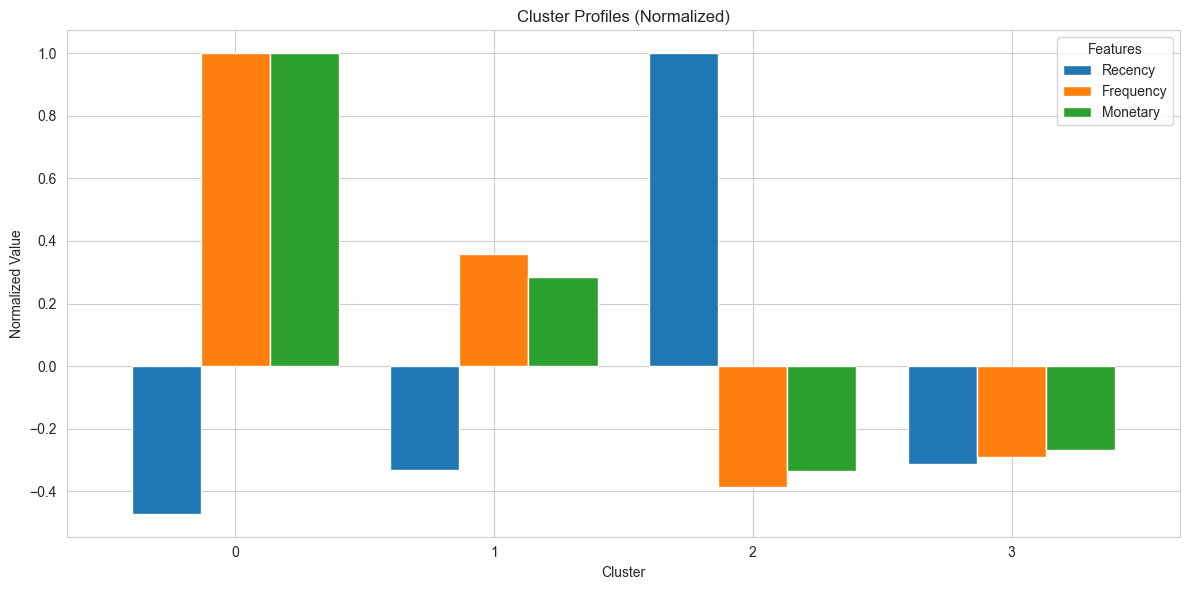

Saved: outputs/figures/09_cluster_profiles.png


In [11]:
# Plot cluster profiles
fig, ax = plt.subplots(figsize=(12, 6))

profile_features = profiles[feature_cols].copy()
for col in feature_cols:
    max_val = profile_features[col].max()
    if max_val > 0:
        profile_features[col] = profile_features[col] / max_val

profile_features['Cluster'] = profiles['Cluster']
profile_features.set_index('Cluster').plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Cluster')
ax.set_ylabel('Normalized Value')
ax.set_title('Cluster Profiles (Normalized)')
ax.legend(title='Features')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../outputs/figures/09_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/figures/09_cluster_profiles.png")

## 5. Save Results

In [12]:
# Save results
top_rules.to_csv('../outputs/tables/03_association_rules.csv', index=False)
profiles.to_csv('../outputs/tables/03_cluster_profiles.csv', index=False)
rfm.to_csv('../data/processed/03_rfm_with_clusters.csv', index=False)

print("Data Mining completed!")
print("Saved:")
print("  - outputs/tables/03_association_rules.csv")
print("  - outputs/tables/03_cluster_profiles.csv")
print("  - data/processed/03_rfm_with_clusters.csv")

Data Mining completed!
Saved:
  - outputs/tables/03_association_rules.csv
  - outputs/tables/03_cluster_profiles.csv
  - data/processed/03_rfm_with_clusters.csv
